In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.stats import multivariate_normal

In [35]:
# ── Paleta CUNEF ──────────────────────────────────────────
CUNEF_ORANGE = "#E8500A"
CUNEF_DARK   = "#1A1A1A"
CUNEF_GRAY   = "#6B6B6B"

cunef_colors = ["#0D0D0D", "#2A1A0E", "#6B2E08",
                CUNEF_ORANGE, "#F4A261", "#FAE3D0"]
cunef_cmap = mcolors.LinearSegmentedColormap.from_list("cunef", cunef_colors, N=256)

mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "figure.facecolor": "#0D0D0D",
    "text.color":       "white",
    "axes.labelcolor":  "white",
    "xtick.color":      CUNEF_GRAY,
    "ytick.color":      CUNEF_GRAY,
})

In [36]:
# Grid
# Rangos más ampios para que los picos respiren
peso   = np.linspace(5,  110, 350)    # kg
altura = np.linspace(80, 210, 350)    # cm
X, Y   = np.meshgrid(peso, altura)
pos    = np.dstack((X, Y))

In [48]:
# 3 gaussianas bien separadas
# Niños: poco peso, poca altura, poca dispersión
mu1  = np.array([22,  112])
cov1 = np.array([[25,  15],
                 [15,  50]])

# Jóvenes: peso medio, altura media-alta
mu2  = np.array([58,  168])
cov2 = np.array([[60,  45],
                 [45,  80]])

# Adultos: más peso, altura similar a jóvenes pero desplazada
mu3  = np.array([85,  177])
cov3 = np.array([[90,  30],
                 [30,  45]])

w1, w2, w3 = 0.28, 0.42, 0.30

Z = (w1 * multivariate_normal(mu1, cov1).pdf(pos) +
     w2 * multivariate_normal(mu2, cov2).pdf(pos) +
     w3 * multivariate_normal(mu3, cov3).pdf(pos))

Zmax = Z.max()

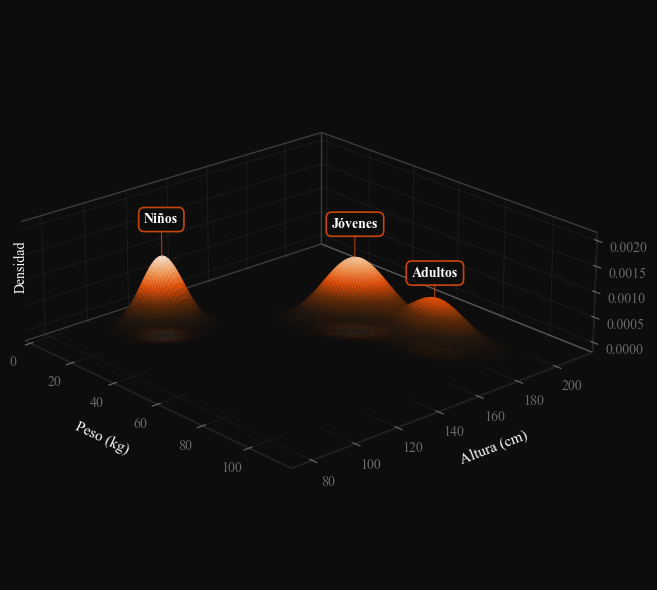

In [63]:
# Figura 
fig = plt.figure(figsize=(17, 6))
fig.patch.set_facecolor("#0D0D0D")

ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#0D0D0D")

ax.set_box_aspect([2.2, 2.2, 0.7])

# Superficie
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cunef_cmap,
    linewidth=0,
    antialiased=True,
    alpha=0.95,
    rcount=250, ccount=250,
)

# Proyección 2D en la base
offset = -0.0002
ax.contourf(X, Y, Z, zdir="z", offset=offset,
            levels=25, cmap=cunef_cmap, alpha=0.25)

# Etiquetas encima de cada pico
# Calculamos la Z real de cada pico para posicionar bien la etiqueta
picos = [
    (mu1[0], mu1[1],
     w1 * multivariate_normal(mu1, cov1).pdf(mu1),  "Niños"),
    (mu2[0], mu2[1],
     w2 * multivariate_normal(mu2, cov2).pdf(mu2),  "Jóvenes"),
    (mu3[0], mu3[1],
     w3 * multivariate_normal(mu3, cov3).pdf(mu3),  "Adultos"),
]

for px, py, pz, nombre in picos:
    # Línea vertical desde el pico hasta la etiqueta
    ax.plot([px, px], [py, py], [pz, pz * 1.35],
            color=CUNEF_ORANGE, linewidth=0.8, alpha=0.7, zorder=10)
    ax.text(px, py, pz * 1.42,
            nombre,
            fontsize=10, color="white", fontweight="bold",
            ha="center", va="bottom",
            zorder=11,
            bbox=dict(facecolor="#0D0D0D", edgecolor=CUNEF_ORANGE,
                      alpha=0.85, boxstyle="round,pad=0.4",
                      linewidth=1.2))

# Ejes
ax.set_xlabel("Peso (kg)",   fontsize=11, color="white", labelpad=12)
ax.set_ylabel("Altura (cm)", fontsize=11, color="white", labelpad=12)
ax.set_zlabel("") 

# Etiqueta manual pegada al eje Z, en coordenadas de figura
ax.text2D(0.01, 0.55, "Densidad",
          transform=ax.transAxes,
          fontsize=10, color="white",
          rotation=90, va="center", ha="center")

# Estilo del cubo 3D
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor(CUNEF_GRAY)

for info in [ax.xaxis._axinfo, ax.yaxis._axinfo, ax.zaxis._axinfo]:
    info["grid"]["color"] = (1, 1, 1, 0.05)

ax.set_zlim(offset, Zmax * 1.55)   # más espacio arriba para las etiquetas

# Ángulo de cámara: los 3 picos quedan todos visibles
ax.view_init(elev=22, azim=-42)

plt.tight_layout()
plt.savefig("images/intratabilidad.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()